<a href="https://colab.research.google.com/github/committed-kermit/ClassicML/blob/main/LogisticRegression_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [2]:
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=20)

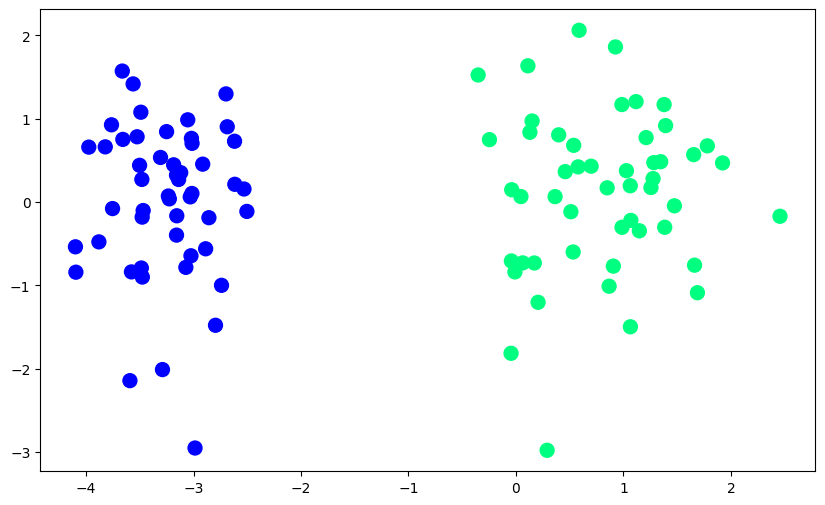

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [8]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [9]:
print(lor.coef_)
print(lor.intercept_)

[[4.79497458 0.20802885]]
[5.76918402]


In [21]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])
print(m1)
print(b1)

-23.049565805653405
[-27.7326156]


In [22]:
x_input = np.linspace(-3,3,100)
y_input = m1*x_input + b1

In [23]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


In [42]:
def gd(X,y):

  X=np.insert(X,0,1,axis=1)
  W=np.ones(X.shape[1])
  lr=0.5

  for i in range(5000):
    y_hat=sigmoid(np.dot(X,W))
    W=W+(lr*(np.dot((y-y_hat),X))/X.shape[0])

  return W[1:],W[0]




In [43]:
coef_,intercept_ = gd(X,y)

In [44]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [45]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

In [46]:
print(m)
print(b)

-22.84586207917223
-27.5390354119192


(-3.0, 2.0)

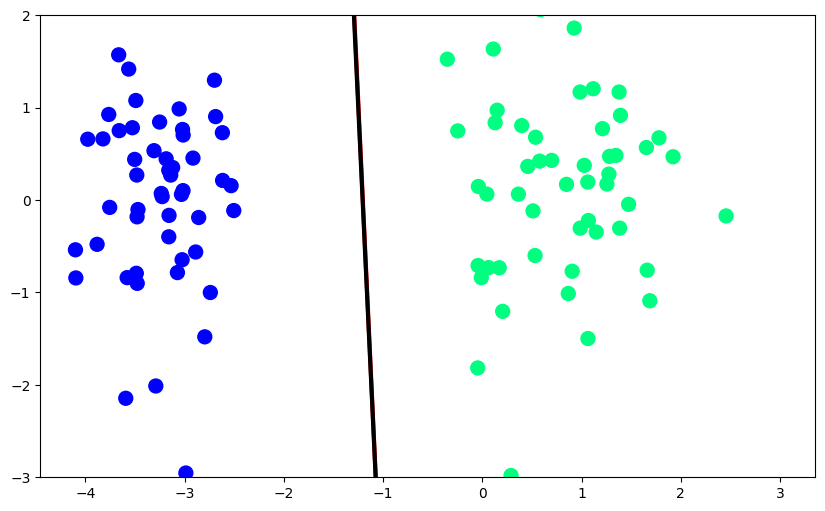

In [47]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)